<h1 style="margin:0;color:#3776AB;">
🐍 Pythonize com Tomane | #012
</h1>

## Criar mapas de pH e carbono orgânico do solo

### 💡 Como transformar amostras de solo com coordenadas num mapa da parcela?

Vamos usar IDW (Inverse Distance Weighting), um método que estima valores entre os pontos medidos dando maior peso às amostras próximas. O resultado é um mapa exploratório: a qualidade da estimativa depende, entre outras coisas, da distribuição das amostras.

#### 1. Instalar e importar as bibliotecas

In [7]:
%pip install numpy matplotlib --q

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

#### 2. Registar as amostras de solo

In [9]:
# As coordenadas x e y estão em metros, numa parcela fictícia de 100 × 100 m.

x = np.array([12, 36, 63, 88, 14, 39, 61, 86,
              13, 37, 64, 88, 11, 38, 62, 87], dtype=float)

y = np.array([12, 13, 11, 14, 36, 38, 37, 36,
              62, 64, 61, 63, 87, 86, 88, 87], dtype=float)

ph = np.array([5.2, 5.4, 5.8, 6.1,
               5.0, 5.3, 5.9, 6.3,
               5.1, 5.6, 6.0, 6.4,
               5.4, 5.7, 6.1, 6.5])

carbono = np.array([0.8, 1.0, 1.1, 1.3,
                    0.7, 0.9, 1.3, 1.5,
                    0.9, 1.1, 1.4, 1.6,
                    1.0, 1.2, 1.5, 1.7])

amostras = np.column_stack((x, y))

#### 3. Criar a função de interpolação

In [10]:
def idw(pontos, valores, locais, potencia=2):
    distancias = np.sqrt(
        ((locais[:, None, :] - pontos[None, :, :]) ** 2).sum(axis=2)
    )

    estimativas = np.empty(len(locais), dtype=float)
    coincide = (distancias == 0).any(axis=1)

    # Num ponto já amostrado, usar o valor medido.
    if np.any(coincide):
        indices = np.argmin(distancias[coincide], axis=1)
        estimativas[coincide] = valores[indices]

    # Nos restantes pontos, calcular a média ponderada pela distância.
    if np.any(~coincide):
        pesos = 1 / distancias[~coincide] ** potencia
        estimativas[~coincide] = (
            pesos @ valores
        ) / pesos.sum(axis=1)

    return estimativas

#### 4. Criar os mapas

In [11]:
coordenadas = np.linspace(0, 100, 101)
X, Y = np.meshgrid(coordenadas, coordenadas)

grelha = np.column_stack((X.ravel(), Y.ravel()))

mapa_ph = idw(amostras, ph, grelha).reshape(X.shape)
mapa_carbono = idw(amostras, carbono, grelha).reshape(X.shape)

distancia_amostras = np.sqrt(
    ((grelha[:, None, :] - amostras[None, :, :]) ** 2).sum(axis=2)
)

mapa_distancia = distancia_amostras.min(axis=1).reshape(X.shape)

#### 5. Visualizar os resultados

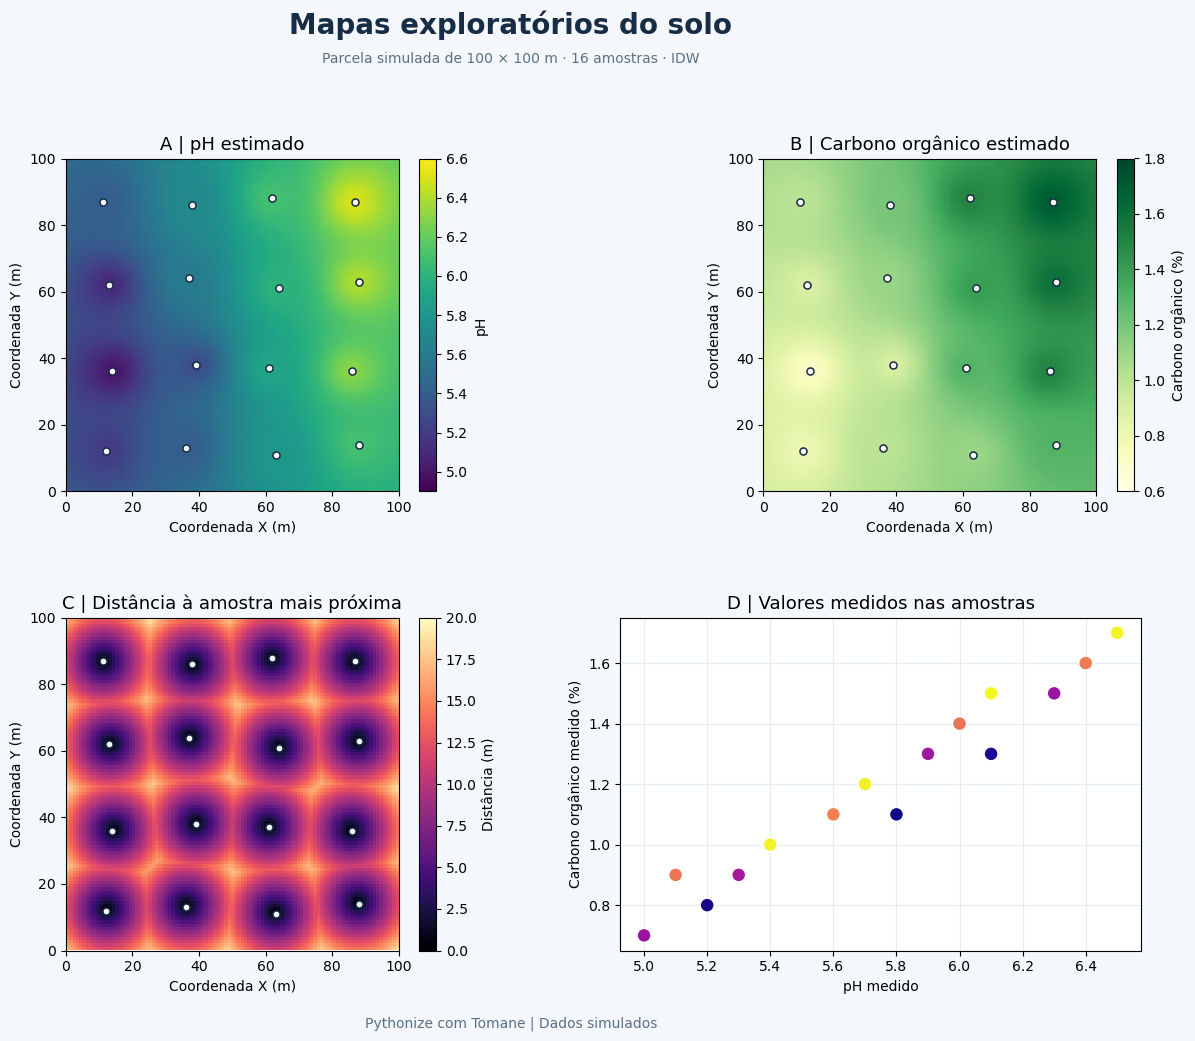

In [12]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 13,
    "figure.facecolor": "#F4F7FB",
})

fig, axs = plt.subplots(2, 2, figsize=(14, 11))

fig.subplots_adjust(
    left=0.08, right=0.95, top=0.84,
    bottom=0.12, wspace=0.34, hspace=0.38
)

fig.suptitle(
    "Mapas exploratórios do solo",
    y=0.975, fontsize=20, fontweight="bold", color="#172C45"
)

fig.text(
    0.5, 0.927,
    "Parcela simulada de 100 × 100 m · 16 amostras · IDW",
    ha="center", color="#5C7184"
)

def desenhar_mapa(ax, dados, titulo, escala, minimo, maximo, unidade):
    imagem = ax.imshow(
        dados,
        origin="lower",
        extent=(0, 100, 0, 100),
        cmap=escala,
        vmin=minimo,
        vmax=maximo
    )

    ax.scatter(
        x, y,
        s=26,
        facecolor="white",
        edgecolor="#172C45",
        linewidth=1.1
    )

    ax.set(
        title=titulo,
        xlabel="Coordenada X (m)",
        ylabel="Coordenada Y (m)",
        xlim=(0, 100),
        ylim=(0, 100),
        aspect="equal"
    )

    fig.colorbar(imagem, ax=ax, label=unidade,
                 fraction=0.046, pad=0.04)

desenhar_mapa(
    axs[0, 0], mapa_ph,
    "A | pH estimado",
    "viridis", 4.9, 6.6, "pH"
)

desenhar_mapa(
    axs[0, 1], mapa_carbono,
    "B | Carbono orgânico estimado",
    "YlGn", 0.6, 1.8, "Carbono orgânico (%)"
)

desenhar_mapa(
    axs[1, 0], mapa_distancia,
    "C | Distância à amostra mais próxima",
    "magma", 0, 20, "Distância (m)"
)

axs[1, 1].scatter(
    ph, carbono,
    c=y,
    cmap="plasma",
    s=100,
    edgecolor="white"
)

axs[1, 1].set(
    title="D | Valores medidos nas amostras",
    xlabel="pH medido",
    ylabel="Carbono orgânico medido (%)"
)

axs[1, 1].grid(color="#E5ECF2")
axs[1, 1].set_axisbelow(True)

fig.text(
    0.5, 0.05,
    "Pythonize com Tomane | Dados simulados",
    ha="center", color="#5C7184"
)

fig.savefig("Pythonize_012_Mapas_Solo.png",
            dpi=180, bbox_inches="tight")

plt.show()

Os pontos brancos mostram onde existem medições. O gráfico C mostra a distância até à amostra mais próxima, ajudando a localizar áreas onde o mapa depende de pontos mais afastados. Isso não é uma medida formal de incerteza; antes de usar um mapa interpolado para tomar decisões no campo, é preciso avaliar a amostragem e verificar as estimativas.

<h3 style="margin-bottom:5px;">
Tomane Mateus
</h3>

<p style="margin-top:0;">
</p>

<p>
🔗 <b>LinkedIn:</b>
<a href="https://www.linkedin.com/in/tomane-mateus-tomane-7a5205123" target="_blank">
www.linkedin.com/in/tomane-mateus-tomane-7a5205123
</a>
</p>
<p>
💻 <b>GitHub:</b>
<a href="https://github.com/Tomane-Pd" target="_blank">
github.com/Tomane-Pd
</a>
</p>
<p>
🌐 <b>Portfolio:</b>
<a href="https://tomane-portfolio.com" target="_blank">
tomane-portfolio.com
</a>
</p>

<hr style="border:1px solid #ddd; width:100%;">

<p style="color:#555;">
 <b>Siga para mais dicas práticas de Python, IA, Data Science e Automação.</b>
</p>

<p style="font-size:13px;color:#888;margin-top:15px;">
© 2026 <b>Tomane Mateus</b>. Todos os direitos reservados.
</p>

</div>